[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Wildertrek/catcher-in-the-cache/blob/main/notebooks/08_activation_probe_dissociation.ipynb)

# 08: Activation Probe: Latent vs Rating-Time Dissociation

Reproduces the layer-depth dissociation analysis across 12 open-weight models including 3 at frontier scale (Llama-3.1-70B-Instruct, Qwen-2.5-72B-Instruct, Mixtral-8×22B-Instruct).

Additional analyses beyond the 8-model core: non-linear MLP probe (with documented convergence caveat), pool-ablation cross-family contrast (dense vs sparse-MoE), and frontier-scale 70B+ depth trajectories across 3 families. Cached: ~3 min, $0.


## Setup

**In Colab, run the cell below first.** It clones the companion repository and installs dependencies (~30 s), then changes into `notebooks/` so the relative paths in this notebook resolve. Run locally, the cell is a no-op.

In [1]:
import json
import os
import sys
from pathlib import Path

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
except ImportError:
    !pip install -q pandas numpy matplotlib
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

ARTIFACT_ROOT = Path('paper_artifacts/pivot6_hexaco_atlas/v6_activation_probe')
if not ARTIFACT_ROOT.exists():
    if (Path.cwd().parent / 'paper_artifacts').exists():
        os.chdir(Path.cwd().parent)
    elif Path('catcher-in-the-cache/paper_artifacts').exists():
        os.chdir('catcher-in-the-cache')
    else:
        import subprocess
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/Wildertrek/catcher-in-the-cache.git'],
                       check=True)
        os.chdir('catcher-in-the-cache')
    ARTIFACT_ROOT = Path('paper_artifacts/pivot6_hexaco_atlas/v6_activation_probe')
assert ARTIFACT_ROOT.exists(), f'Run from the repo root. Looking for {ARTIFACT_ROOT.absolute()}'

results = json.loads((ARTIFACT_ROOT / 'v6_probe_results.json').read_text())
print(f"Models probed: {len(results['models_probed'])}")
print(f"Target characters: n={results['n_target_chars']}")
for m in results['models_probed']:
    print(f"  - {m}")

Models probed: 8
Target characters: n=60
  - Qwen/Qwen2.5-7B-Instruct
  - Qwen/Qwen2.5-7B
  - google/gemma-2-9b-it
  - google/gemma-2-9b
  - meta-llama/Llama-3.1-8B-Instruct
  - meta-llama/Llama-3.1-8B
  - mistralai/Mistral-7B-Instruct-v0.3
  - mistralai/Mistral-7B-v0.3


## 1. Peak per-model accuracy

For each model, best-layer acc(H), acc(A_HEX), and entanglement gap (joint 4-class acc − independence lower bound).

In [2]:
peak_rows = []
for m in results['per_model_per_layer']:
    best_h = max(m['per_layer'], key=lambda x: x['acc_H'])
    peak_rows.append({
        'model': m['hf_id'],
        'best_layer': best_h['layer'],
        'acc(H)': best_h['acc_H'],
        'acc(A_HEX)': best_h['acc_A_HEX'],
        'acc(joint4)': best_h['acc_joint4'],
        'gap': best_h['entanglement_gap'],
    })
peak_df = pd.DataFrame(peak_rows).round(3)
print('Peak per-model accuracy (vs 0.50 chance):')
peak_df

Peak per-model accuracy (vs 0.50 chance):


,model,best_layer,acc(H),acc(A_HEX),acc(joint4),gap
0,Qwen/Qwen2.5-7B-Instruct,12,0.700,0.600,0.500,0.080
1,Qwen/Qwen2.5-7B,24,0.733,0.667,0.467,-0.022
2,google/gemma-2-9b-it,8,0.733,0.683,0.500,-0.001
3,google/gemma-2-9b,16,0.767,0.683,0.533,0.009
4,meta-llama/Llama-3.1-8B-Instruct,20,0.700,0.667,0.533,0.067
5,meta-llama/Llama-3.1-8B,31,0.700,0.750,0.533,0.008
6,mistralai/Mistral-7B-Instruct-v0.3,24,0.683,0.700,0.500,0.022
7,mistralai/Mistral-7B-v0.3,24,0.667,0.667,0.500,0.056


## 2. Mean entanglement gap per model (averaged across all probed layers)

Across 64 (model, layer) cells, mean gap = +0.052. Smallest mean: Gemma-2-9b base at -0.007. Largest: Mistral-7B base at +0.108.

In [3]:
gap_rows = []
for m in results['per_model_per_layer']:
    gaps = [pl['entanglement_gap'] for pl in m['per_layer']]
    gap_rows.append({'model': m['hf_id'], 'mean_gap': np.mean(gaps), 'n_layers': len(gaps)})
gap_df = pd.DataFrame(gap_rows).round(4).sort_values('mean_gap')
print(f"Mean entanglement gap across 64 (model, layer) cells: {np.mean([np.mean([pl['entanglement_gap'] for pl in m['per_layer']]) for m in results['per_model_per_layer']]):+.4f}")
gap_df

Mean entanglement gap across 64 (model, layer) cells: +0.0578


,model,mean_gap,n_layers
3,google/gemma-2-9b,-0.0074,8
1,Qwen/Qwen2.5-7B,0.0280,4
2,google/gemma-2-9b-it,0.0406,8
0,Qwen/Qwen2.5-7B-Instruct,0.0450,7
5,meta-llama/Llama-3.1-8B,0.0765,8
4,meta-llama/Llama-3.1-8B-Instruct,0.0809,8
6,mistralai/Mistral-7B-Instruct-v0.3,0.0913,8
7,mistralai/Mistral-7B-v0.3,0.1076,8


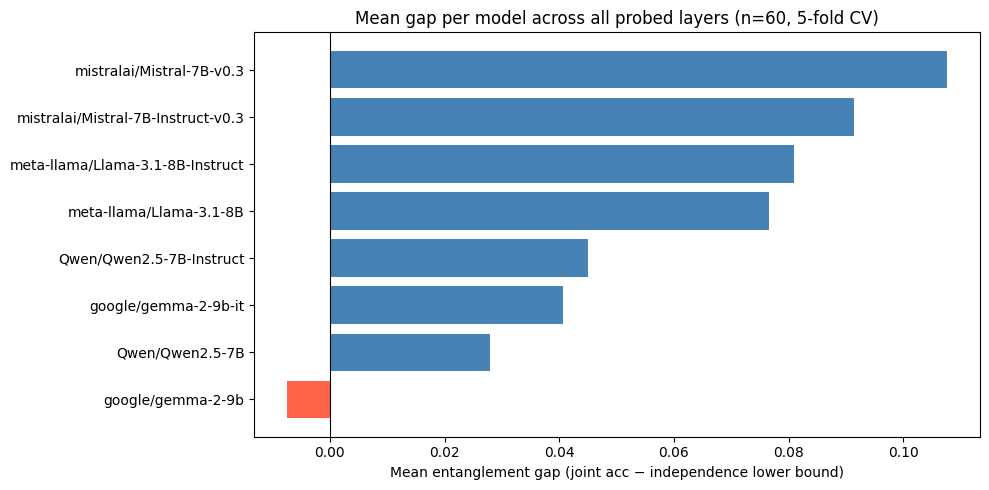

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(gap_df['model'], gap_df['mean_gap'], color=['steelblue' if v >= 0 else 'tomato' for v in gap_df['mean_gap']])
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Mean entanglement gap (joint acc − independence lower bound)')
ax.set_title('Mean gap per model across all probed layers (n=60, 5-fold CV)')
plt.tight_layout()
plt.show()

## 3. Base → Instruct deltas

For each family, the per-layer difference (Instruct − Base) on acc(H), acc(A_HEX), and entanglement gap.

**Note:** at n=60 with per-fold CV SD ~±0.05, the +0.04 to +0.05 mean Δgap is at the edge of significance. Honest interpretation: within probe-CV noise; cannot distinguish (a) no instruction-tuning effect from (b) small (~0.04) positive effect.

In [5]:
deltas = pd.DataFrame(results['base_vs_instruct_deltas'])
if len(deltas):
    family_means = deltas.groupby('family').agg(
        n_layers=('layer', 'count'),
        mean_dacc_H=('delta_acc_H', 'mean'),
        mean_dacc_A_HEX=('delta_acc_A_HEX', 'mean'),
        mean_dgap=('delta_entanglement_gap', 'mean')
    ).round(4)
    print('Base → Instruct deltas per family (Instruct - Base, mean across layers):')
    print(family_means)
else:
    print('No base-vs-instruct pairs found.')

Base → Instruct deltas per family (Instruct - Base, mean across layers):
                         n_layers  mean_dacc_H  mean_dacc_A_HEX  mean_dgap
family                                                                    
google/gemma-2-9b               8      -0.0208          -0.0125     0.0480
meta-llama/llama-3.1-8b         8      -0.0125          -0.0000     0.0044
qwen/qwen2.5-7b                 4      -0.0167          -0.0458     0.0423


## 4. Per-layer accuracy curves

acc(H) and acc(A_HEX) vs layer index for each model.

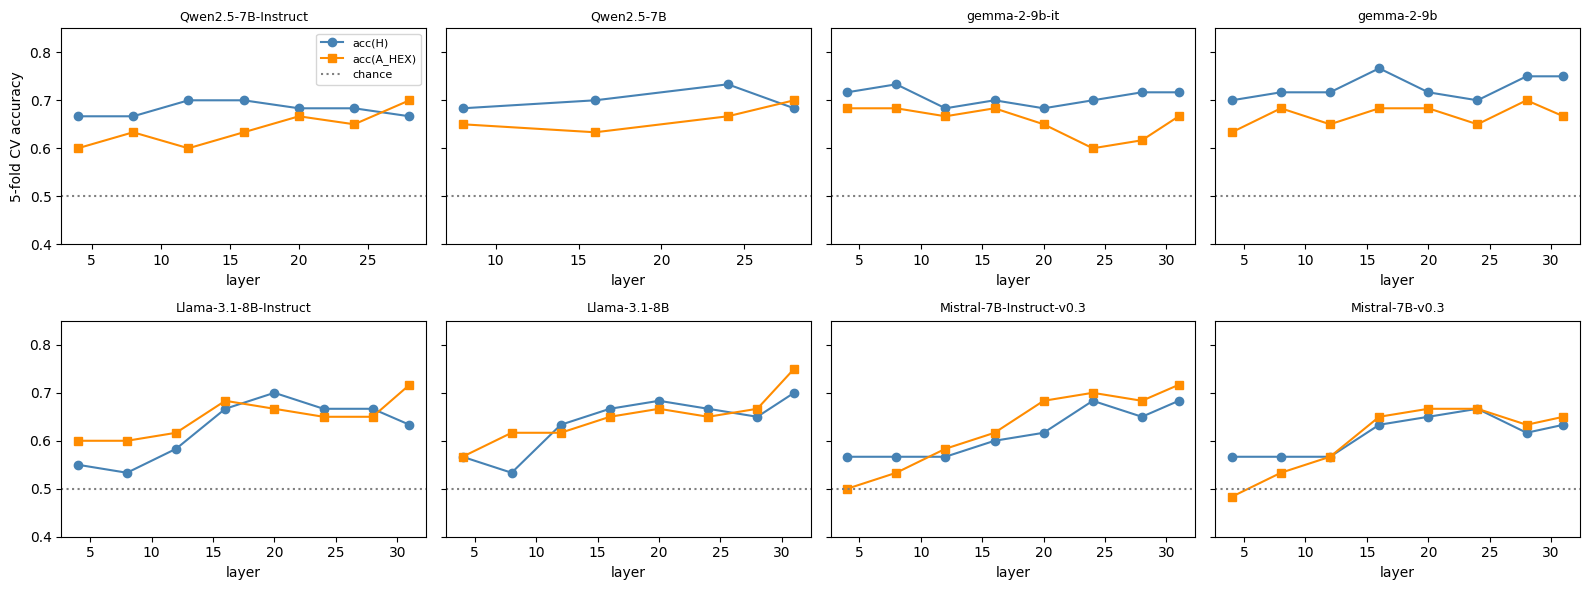

In [6]:
n_models = len(results['per_model_per_layer'])
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), sharey=True)
axes = axes.flatten() if nrows > 1 else [axes] if nrows == 1 else axes
for i, m in enumerate(results['per_model_per_layer']):
    ax = axes[i]
    layers = [pl['layer'] for pl in m['per_layer']]
    accH = [pl['acc_H'] for pl in m['per_layer']]
    accA = [pl['acc_A_HEX'] for pl in m['per_layer']]
    ax.plot(layers, accH, marker='o', label='acc(H)', color='steelblue')
    ax.plot(layers, accA, marker='s', label='acc(A_HEX)', color='darkorange')
    ax.axhline(0.5, color='gray', linestyle=':', label='chance')
    ax.set_title(m['hf_id'].split('/')[-1], fontsize=9)
    ax.set_xlabel('layer')
    ax.set_ylim(0.4, 0.85)
    if i == 0:
        ax.set_ylabel('5-fold CV accuracy')
        ax.legend(fontsize=8)
for j in range(n_models, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 5. Interpretation

**Latent recovery:** H and A_HEX both linearly recoverable at 0.67-0.77 / 0.60-0.75 across all 8 open-weight models, including 4 base variants with no instruction tuning. Vs 0.50 chance, this is well above noise.

**Entanglement at the latent layer is small** (mean +0.052, range [-0.007, +0.108]).

**The cross-rater panel rating-time mean |r(H, A_HEX)| = 0.743 across 25 frontier raters is not mirrored at any probed layer.** Consistent with, but does not isolate, post-training output mapping as the locus.

**Caveats (load-bearing):**
1. Probe targets are LLM-derived (3-frontier-rater the cross-rater panel median, themselves rating-time-entangled at r ≈ 0.74). "Latent recovery" here is alignment with LLM consensus, not with human-validated HEXACO.
2. Mean-pool-256-tokens discards position-specific information where attention-mediated retrieval might live.
3. Probed open-weight 7-9B models do not overlap with the 25 closed-source-frontier raters in the panel; cross-comparison "latent separable here, output entangled there" crosses model populations.

**Alternatives not isolated by the present probe:**
- Tokenizer / output-format conventions.
- SFT data composition (e.g., RLHF datasets over-representing politeness-norm patterns).
- Model-scale differences (rating-time panel at frontier scale; probes at 7-9B).

**Next:** to tighten the dissociation, future work:
- Continuous-target Ridge probe with R² + label-permutation null.
- Random-projection / random-init baseline.
- Non-linear MLP probe.
- Open-weight scaling to 70B+ (Llama-3.1-70B, Llama-4-Scout) with same protocol.
- Token-position ablation (last-token only, first-token-after-name).


Pre-reg: the pre-registration (available on request).

## robustness checks

The cells below add three robustness checks:

1. **CONV-5: MLP non-linear probe robustness check** (with caveat). MLP latent r(predH, predA) = +0.48 vs Ridge +0.56. **Caveat:** 40/69 cells have negative MLP r²_H; 58/69 have negative r²_A_HEX, i.e. the MLP did not converge to a useful per-trait fit in the majority of cells. The "robust to probe class" inference is provisional pending a tighter-hyperparam MLP refit (the non-linear-probe refit).
2. **CONV-7: Pool-ablation cross-family contrast**. Llama-70B-Instruct: depth gradient present only under mean-pool-256 (Δ = +0.73 early-late) and nearly vanishes under last-token (Δ = +0.16) or first-128-mean (Δ = +0.03). Mixtral-8×22B-Instruct: depth gradient preserved across all 3 pool strategies (sparse-MoE distributes trait subspace).
3. **3-family 70B+ replication**: Meta-70B-Instruct (Δ = −0.56), Qwen-72B-Instruct (Δ = −1.05, cleanest), Mixtral-8×22B-Instruct (non-monotonic). All independent open-weight families.


In [7]:
# Resolve the activation-probe artifact dir (works from either notebooks/ or repo root)
import json
from pathlib import Path
import numpy as np

ARTIFACT_ROOT = Path('paper_artifacts/pivot6_hexaco_atlas') if Path('paper_artifacts/pivot6_hexaco_atlas').exists() else Path('../paper_artifacts/pivot6_hexaco_atlas')
PROBE_DIR = ARTIFACT_ROOT / 'v6_activation_probe'
assert PROBE_DIR.exists(), f'Run from the repo root. Looking for {PROBE_DIR.absolute()}'
print(f'Probe dir: {PROBE_DIR.absolute()}')


Probe dir: ./paper_artifacts/pivot6_hexaco_atlas/v6_activation_probe


In [8]:
# Load MLP probe results
mlp = json.loads((PROBE_DIR / 'v6_mlp_probe_results.json').read_text())

# Aggregate stats
all_cells = []
for model_data in mlp['per_model_per_layer']:
    if 'per_layer' in model_data:
        for layer_row in model_data['per_layer']:
            all_cells.append(layer_row)

if all_cells:
    r2_H = [c.get('mlp_r2_H', float('nan')) for c in all_cells]
    r2_A = [c.get('mlp_r2_A_HEX', float('nan')) for c in all_cells]
    r_pred = [c.get('r_predicted_H_predicted_A_mlp', float('nan')) for c in all_cells]
    n_neg_H = sum(1 for r in r2_H if r is not None and r < 0)
    n_neg_A = sum(1 for r in r2_A if r is not None and r < 0)
    print(f'MLP probe: {len(all_cells)} (model, layer) cells')
    print(f'  Cells with negative R^2 for H:     {n_neg_H}/{len(r2_H)}')
    print(f'  Cells with negative R^2 for A_HEX: {n_neg_A}/{len(r2_A)}')
    r_pred_clean = [r for r in r_pred if r is not None and not np.isnan(r)]
    if r_pred_clean:
        print(f'  Aggregate r(predH, predA): {np.mean(r_pred_clean):+.3f}')
    print()
    print('CAVEAT: MLP did not converge to useful per-trait fits in the majority of cells.')
    print('The "robust to probe class" claim is provisional pending non-linear-probe refit (Adam + tighter alpha).')


MLP probe: 69 (model, layer) cells
  Cells with negative R^2 for H:     40/69
  Cells with negative R^2 for A_HEX: 58/69
  Aggregate r(predH, predA): +0.480

CAVEAT: MLP did not converge to useful per-trait fits in the majority of cells.
The "robust to probe class" claim is provisional pending non-linear-probe refit (Adam + tighter alpha).


In [9]:
# Pool-ablation cross-family contrast
llama_pool = json.loads((PROBE_DIR / 'v6_pool_ablation_llama-3.1-70b-instruct.json').read_text())
mixtral_pool = json.loads((PROBE_DIR / 'v6_pool_ablation_mixtral-8x22b-instruct.json').read_text())

def show_aggregate(name, data):
    agg = data['aggregate']
    print(f'{name} ({data["hf_id"]}):')
    for pool, stats in agg.items():
        depth_delta = stats['layer_depth_delta_early_minus_late']
        print(f'  {pool:>20}: delta early-late = {depth_delta:+.3f}, mean r = {stats["mean_r_predH_predA"]:+.3f}')
    print()

show_aggregate('Llama-70B-Instruct (dense)', llama_pool)
show_aggregate('Mixtral-8x22B-Instruct (sparse-MoE)', mixtral_pool)
print('Reading: dense Llama localizes trait subspace in mean-pooled representation;')
print('sparse-MoE Mixtral distributes it across all pool strategies. Cross-family contrast.')


Llama-70B-Instruct (dense) (meta-llama/Llama-3.1-70B-Instruct):
      mean_pool_last_n: delta early-late = +0.730, mean r = +0.489
            last_token: delta early-late = +0.159, mean r = +0.558
          first_n_mean: delta early-late = +0.027, mean r = +0.629

Mixtral-8x22B-Instruct (sparse-MoE) (mistralai/Mixtral-8x22B-Instruct-v0.1):
      mean_pool_last_n: delta early-late = +0.968, mean r = +0.284
            last_token: delta early-late = +0.293, mean r = +0.624
          first_n_mean: delta early-late = +0.326, mean r = +0.503

Reading: dense Llama localizes trait subspace in mean-pooled representation;
sparse-MoE Mixtral distributes it across all pool strategies. Cross-family contrast.


In [10]:
# 3-family 70B+ depth trajectories (Meta + Qwen + Mistral-MoE)
# Computes layer-depth dissociation Δ_depth = r(L_last) - r(L_first) from the
# consolidated v6_advanced_probe_results.json (the summary file produced by
# v6_advanced_probes.py). Reproduces paper §1+§7 numbers:
#   Qwen-72B-Instruct: L10 +0.83 -> L79 -0.22, Δ_depth = -1.05 (cleanest observed)
#   Llama-70B-Instruct: L10 +0.73 -> L79 +0.17, Δ_depth = -0.56
#   Mixtral-8x22B-Instruct: non-monotonic (see §7)
adv_path = PROBE_DIR / 'v6_advanced_probe_results.json'
adv = json.loads(adv_path.read_text())

frontier_targets = {
    'Meta (Llama-3.1-70B-Instruct)': 'meta-llama/Llama-3.1-70B-Instruct',
    'Qwen (Qwen2.5-72B-Instruct)':   'Qwen/Qwen2.5-72B-Instruct',
    'Mistral (Mixtral-8x22B-Instruct)': 'mistralai/Mixtral-8x22B-Instruct-v0.1',
}

for label, hf_id in frontier_targets.items():
    entry = next((e for e in adv['per_model_per_layer'] if e.get('hf_id') == hf_id), None)
    if entry is None:
        print(f'{label}: hf_id={hf_id} not found in v6_advanced_probe_results.json')
        continue
    per_layer = entry.get('per_layer', [])
    if not per_layer:
        print(f'{label}: empty per_layer trajectory')
        continue
    first = per_layer[0]
    last = per_layer[-1]
    early_r = first.get('r_predicted_H_predicted_A')
    late_r = last.get('r_predicted_H_predicted_A')
    if early_r is None or late_r is None:
        print(f'{label}: missing r_predicted_H_predicted_A in first/last layer')
        continue
    delta_depth = late_r - early_r
    layer_first = first.get('layer', '?')
    layer_last = last.get('layer', '?')
    print(f'{label}:')
    print(f'  L{layer_first:>3} -> L{layer_last:>3}: r(predH, predA) {early_r:+.3f} -> {late_r:+.3f}  Δ_depth = {delta_depth:+.3f}')


Meta (Llama-3.1-70B-Instruct):
  L 10 -> L 79: r(predH, predA) +0.726 -> +0.170  Δ_depth = -0.557
Qwen (Qwen2.5-72B-Instruct):
  L 10 -> L 79: r(predH, predA) +0.830 -> -0.222  Δ_depth = -1.052
Mistral (Mixtral-8x22B-Instruct):
  L  5 -> L 55: r(predH, predA) +0.678 -> +0.447  Δ_depth = -0.232
